In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [3]:
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)

/home/awelch/GIPL/snow_experiment


In [5]:
import pandas as pd
import numpy as np

# Load the data (adjust the file path as needed)
df = pd.read_csv(WD_PATH/'data/control_snow_depth.txt', sep=r'\s+', names=['day', 'snow_depth'])

# Print the first few rows and data info for debugging
print(df.head())
print(df.info())

# Constants
days_per_year = 365
num_years = 10
total_days = days_per_year * num_years
winter_days = 60

# Ensure we have 10 years of data
if len(df) < total_days:
    raise ValueError(f"Not enough data. Expected {total_days} days, but got {len(df)} days.")

# Calculate the total increase factor over 10 years
total_increase_factor = 1.15  # 15% increase

# Function to apply snow depth increase for winter days
def increase_snow_depth(snow_depth, day_of_year, year):
    if day_of_year <= winter_days and snow_depth > 0:
        # Calculate the increase factor for this year
        year_factor = 1 + (total_increase_factor - 1) * (year + 1) / num_years
        return snow_depth * year_factor
    return snow_depth

# Apply gradual snow depth increase
df['modified_snow_depth'] = df.apply(lambda row: increase_snow_depth(
    row['snow_depth'], 
    row['day'] % days_per_year, 
    row['day'] // days_per_year
), axis=1)

# Print some values for debugging
print("\nFirst few rows after modification:")
print(df.head())
print("\nLast few rows after modification:")
print(df.tail())

# Print some statistics for debugging
print("\nStatistics of the original snow depth:")
print(df['snow_depth'].describe())
print("\nStatistics of the modified snow depth:")
print(df['modified_snow_depth'].describe())

# Verify the snow depth increase
avg_snow_year1 = df.loc[0:days_per_year-1, 'snow_depth'].mean()
avg_snow_year10 = df.loc[9*days_per_year:10*days_per_year-1, 'modified_snow_depth'].mean()
print(f"\nAverage snow depth in Year 1 (original): {avg_snow_year1:.2f} m")
print(f"Average snow depth in Year 10 (modified): {avg_snow_year10:.2f} m")
print(f"Snow depth increase: {(avg_snow_year10 - avg_snow_year1) / avg_snow_year1 * 100:.2f}%")

# Verify winter snow depth increase
winter_snow_year1 = df.loc[0:winter_days-1, 'snow_depth'].mean()
winter_snow_year10 = df.loc[9*days_per_year:9*days_per_year+winter_days-1, 'modified_snow_depth'].mean()
print(f"\nAverage winter snow depth in Year 1 (original): {winter_snow_year1:.2f} m")
print(f"Average winter snow depth in Year 10 (modified): {winter_snow_year10:.2f} m")
print(f"Winter snow depth increase: {(winter_snow_year10 - winter_snow_year1) / winter_snow_year1 * 100:.2f}%")

# Optional: Save the modified data to a new file
# df.to_csv(WD_PATH/'data/modified_snow_depth.txt', sep=' ', index=False)
# print("\nModified snow depth data saved to 'modified_snow_depth.txt'")

   day  snow_depth
0    1        0.43
1    2        0.43
2    3        0.43
3    4        0.43
4    5        0.41
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         3650 non-null   int64  
 1   snow_depth  3650 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 57.2 KB
None

First few rows after modification:
   day  snow_depth  modified_snow_depth
0    1        0.43              0.43645
1    2        0.43              0.43645
2    3        0.43              0.43645
3    4        0.43              0.43645
4    5        0.41              0.41615

Last few rows after modification:
       day  snow_depth  modified_snow_depth
3645  3646        0.46               0.4600
3646  3647        0.46               0.4600
3647  3648        0.46               0.4600
3648  3649        0.46               0.4600
3649  3650        0.50       

In [8]:
# Save the modified data
df_filtered = df.iloc[:, [0, 2]]
df_filtered.to_csv(WD_PATH/'data/modified_snow_depth_data.txt', sep='\t', index=False)
print("Modified data saved to 'modified_snow_depth_data.txt'")

Modified data saved to 'modified_snow_depth_data.txt'


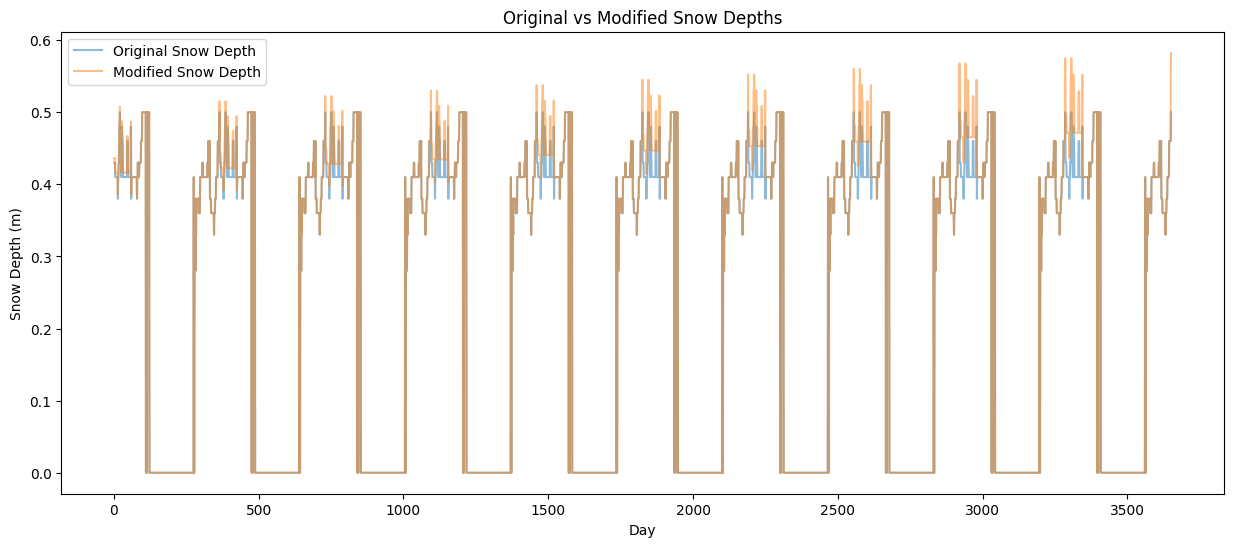

In [7]:
# Optional: Plot the original and modified temperatures
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df['day'], df['snow_depth'], label='Original Snow Depth', alpha=0.5)
plt.plot(df['day'], df['modified_snow_depth'], label='Modified Snow Depth', alpha=0.5)
plt.xlabel('Day')
plt.ylabel('Snow Depth (m)')
plt.title('Original vs Modified Snow Depths')
plt.legend()
# plt.savefig('temperature_comparison.png')
plt.show()
# plt.close()

# print("Temperature comparison plot saved as 'temperature_comparison.png'")